# Playground Series S6E4 — Walkthrough

End-to-end **EDA → model → tune → submit**, built from first principles.

- **Task.** Predict `Irrigation_Need` ∈ {Low, Medium, High}.
- **Metric.** Balanced Accuracy (macro-average of per-class recall).
- **Data.** 630k train rows, 270k test rows, 20 features (11 numeric + 8 categorical + `id`).

**Plan.**
1. Load + sanity check.
2. Target distribution → understand class imbalance.
3. Univariate signal — *not* via Pearson (we'll show why).
4. LightGBM with stratified 5-fold CV + class weights.
5. Confusion matrix + feature importance.
6. Post-hoc threshold tuning on OOF probabilities.
7. Test prediction → submission.

This notebook is **self-contained**: every line of logic lives here. To run on Kaggle, only `DATA_DIR` needs to change.

## 0. Configuration

`FAST_MODE` controls runtime. The full 630k run takes ~3–6 min CPU; the fast subsample (100k, *stratified* — preserves the 58.7 / 38.0 / 3.3 prior) finishes in ~30s. A *balanced* subset (equal class counts) would distort the prior and break the post-hoc threshold tuning, so we keep stratified subsampling.

In [1]:
# ============================================================
# Configuration — edit these to suit your environment
# ============================================================
FAST_MODE        = True        # True: 100k stratified subsample. False: full 630k.
FAST_SAMPLE_SIZE = 100_000

DATA_DIR         = "../data"   # Kaggle: "/kaggle/input/playground-series-s6e4"
SUBMISSION_PATH  = "../submissions/sub_walkthrough.csv"

SEED      = 42
N_SPLITS  = 5

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
np.random.seed(SEED)

## 1. Load & inspect

Cheap checks first: shape, dtypes, missing values, duplicates. If anything is unexpected here, every downstream conclusion is suspect.

In [27]:
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

TARGET = "Irrigation_Need"
ID_COL = "id"

print(f"train: {train.shape}")
print(f"test : {test.shape}")
train.head()

train: (630000, 21)
test : (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [8]:
# Sanity checks
print("Missing values  — train:", train.isna().sum().sum(),
      " test:", test.isna().sum().sum())
print("Duplicates (excluding id):",
      train.drop(columns=[ID_COL]).duplicated().sum())
print("\ndtypes:")
print(train.dtypes.value_counts())

Missing values  — train: 0  test: 0
Duplicates (excluding id): 0

dtypes:
float64    11
object      9
int64       1
Name: count, dtype: int64


**No missing, no duplicates.** This is synthetic, very clean data — modeling effort goes into signal extraction and imbalance handling, not cleanup.

## 2. Target distribution

Before *anything* else: how is the target distributed? Under Balanced Accuracy, this number drives every modeling decision.

In [9]:
class_counts = train[TARGET].value_counts()
class_pct    = train[TARGET].value_counts(normalize=True) * 100

dist = pd.DataFrame({"count": class_counts, "pct (%)": class_pct.round(2)})
dist.loc["TOTAL"] = [class_counts.sum(), 100.00]
dist

,count,pct (%)
Irrigation_Need,,
Low,369917.0,58.72
Medium,239074.0,37.95
High,21009.0,3.33
TOTAL,630000.0,100.00


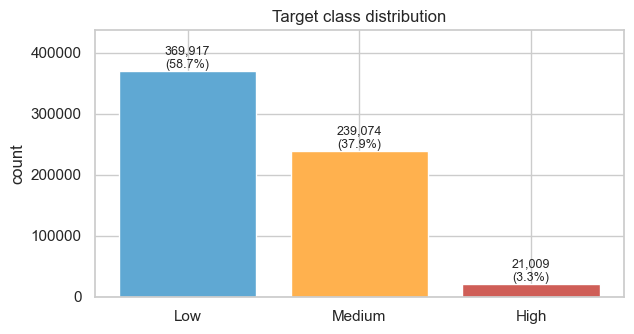

In [10]:
order  = ["Low", "Medium", "High"]
counts = class_counts.reindex(order)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
bars = ax.bar(order, counts.values, color=["#5fa8d3", "#ffb14e", "#cf5e57"])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v,
            f"{v:,}\n({v/counts.sum():.1%})",
            ha="center", va="bottom", fontsize=9)
ax.set_title("Target class distribution")
ax.set_ylabel("count")
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout(); plt.show()

**Why the imbalance dictates everything.**

- "Always predict Low" scores BalAcc = 1/3 = **0.333** — the rare class `High` is worth 1/3 of the metric on its own.
- We must use **stratified k-fold** — random k-fold could produce a fold with 1.3% High by luck (noisy CV, unstable threshold tuning).
- We must use **class weights** (or a cost-sensitive loss) — otherwise the model under-predicts High and the metric collapses.
- Argmax-of-softmax minimizes log-loss, *not* BalAcc — we'll **tune decision thresholds on OOF** later.

## 3. Feature types & cardinalities

In [14]:
features = [c for c in train.columns if c not in (ID_COL, TARGET)]
cat_cols  = train[features].select_dtypes(include="object").columns.tolist()
num_cols  = [c for c in features if c not in cat_cols]

print(f"{len(num_cols)} numeric  : {num_cols}")
print(f"\n{len(cat_cols)} categorical: {cat_cols}")

11 numeric  : ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

8 categorical: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


In [15]:
card = pd.DataFrame({
    "cardinality": [train[c].nunique() for c in cat_cols],
    "levels":      [", ".join(sorted(map(str, train[c].unique()))) for c in cat_cols],
}, index=cat_cols)
card

,cardinality,levels
Soil_Type,4,"Clay, Loamy, Sandy, Silt"
Crop_Type,6,"Cotton, Maize, Potato, Rice, Sugarcane, Wheat"
Crop_Growth_Stage,4,"Flowering, Harvest, Sowing, Vegetative"
Season,3,"Kharif, Rabi, Zaid"
Irrigation_Type,4,"Canal, Drip, Rainfed, Sprinkler"
Water_Source,4,"Groundwater, Rainwater, Reservoir, River"
Mulching_Used,2,"No, Yes"
Region,5,"Central, East, North, South, West"


All categoricals are low-cardinality (2–6 levels). One-hot vs ordinal vs LightGBM-native won't matter much; we'll let LightGBM handle them natively.

## 4. Why the correlation matrix lies on this dataset

If you encode `Irrigation_Need` as 0/1/2 and call `df.corr()`, every numeric feature looks like noise (|r| < 0.15). That misled my first instincts. Three reasons:

1. **The target is ordinal-categorical.** Pearson measures *linear* association. Group separation (e.g., `Soil_Moisture` mean = 43 in Low vs 18 in High) doesn't show up linearly.
2. **The signal is multivariate.** "High need" is a *conjunction* — low moisture **AND** hot **AND** windy. Each ingredient looks weak alone.
3. **Imbalance hides effects.** A feature that perfectly identifies the 3.3% High class barely moves the global Pearson with target.

Right diagnostics for this kind of data:
- **Group-by-target statistics** for numerics (means, medians per class).
- **Conditional proportions** for categoricals (`P(class | level)`).
- **Mutual information** as a non-linear sanity check.

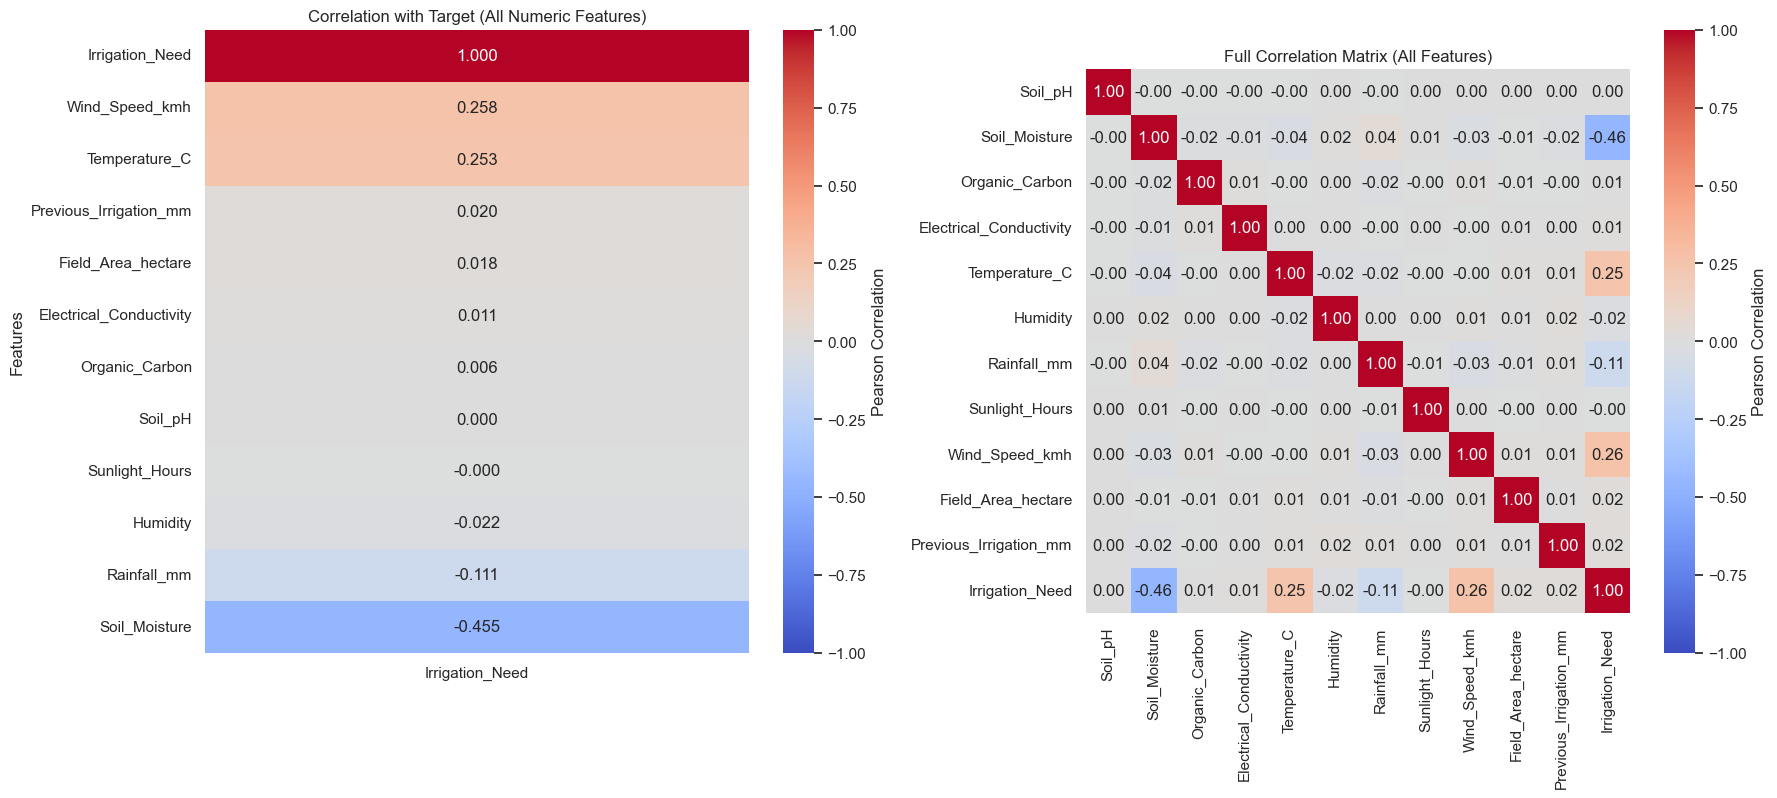

In [ ]:
#### this cell is for demonstration, not cleaned coupled properly 
# Drop id and index columns
train_clean = train.drop(columns=['id', 'index'], errors='ignore')
 
# Map target to numeric
y_numeric = train_clean[TARGET].map({"Low": 0, "Medium": 1, "High": 2})
 
# Create a copy with numeric target for correlation
train_corr = train_clean.copy()
train_corr[TARGET] = y_numeric
 
# Calculate correlation matrix (includes all numeric columns + target)
corr_matrix = train_corr.corr(numeric_only=True)
 
# Extract correlations with target only
target_corr = corr_matrix[[TARGET]].sort_values(by=TARGET, ascending=False)
 
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
 
# Heatmap 1: Target correlations only (like your code, but as heatmap)
sns.heatmap(target_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Pearson Correlation'}, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlation with Target (All Numeric Features)')
axes[0].set_ylabel('Features')
 
# Heatmap 2: Full correlation matrix (all variables with each other)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Pearson Correlation'}, ax=axes[1], vmin=-1, vmax=1,
            square=True)
axes[1].set_title('Full Correlation Matrix (All Features)')
 
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
y_int = train[TARGET].map({"Low": 0, "Medium": 1, "High": 2}).values

pearson = pd.Series(
    {c: np.corrcoef(train[c], y_int)[0, 1] for c in num_cols},
    name="pearson_r",
)
pearson.abs().sort_values(ascending=False).round(3).to_frame("|pearson_r|")

,|pearson_r|
Soil_Moisture,0.455
Wind_Speed_kmh,0.258
Temperature_C,0.253
Rainfall_mm,0.111
Humidity,0.022
Previous_Irrigation_mm,0.020
Field_Area_hectare,0.018
Electrical_Conductivity,0.011
Organic_Carbon,0.006
Sunlight_Hours,0.000


Now compare to mutual information, which captures non-linear dependence.

In [30]:
# MI on a 100k sample for speed (full 630k is slow; ranking is stable).
sample_idx = np.random.RandomState(SEED).choice(
    len(train), size=min(100_000, len(train)), replace=False
)
X_mi = train[features].iloc[sample_idx].copy()
for c in cat_cols:
    X_mi[c] = LabelEncoder().fit_transform(X_mi[c].astype(str))
y_mi = y_int[sample_idx]

mi_scores = mutual_info_classif(
    X_mi, y_mi,
    discrete_features=[X_mi.columns.get_loc(c) for c in cat_cols],
    random_state=SEED,
)
mi = pd.Series(mi_scores, index=features, name="mutual_info")
mi.sort_values(ascending=False).round(4).to_frame()

,mutual_info
Soil_Moisture,0.2040
Rainfall_mm,0.1889
Crop_Growth_Stage,0.1659
Temperature_C,0.0745
Wind_Speed_kmh,0.0633
Humidity,0.0484
Previous_Irrigation_mm,0.0482
Mulching_Used,0.0471
Field_Area_hectare,0.0146
Electrical_Conductivity,0.0117


In [11]:
# Side by side: Pearson rank vs MI rank
ranking = pd.concat(
    [pearson.abs().rename("|pearson|"), mi.rename("MI")],
    axis=1,
).fillna(0)
ranking["pearson_rank"] = ranking["|pearson|"].rank(ascending=False).astype(int)
ranking["MI_rank"]      = ranking["MI"].rank(ascending=False).astype(int)
ranking.sort_values("MI_rank")

,|pearson|,MI,pearson_rank,MI_rank
Soil_Moisture,0.455482,0.204023,1,1
Rainfall_mm,0.111478,0.188896,4,2
Crop_Growth_Stage,0.000000,0.165946,15,3
Temperature_C,0.252867,0.074547,3,4
Wind_Speed_kmh,0.258170,0.063347,2,5
Humidity,0.021870,0.048447,5,6
Previous_Irrigation_mm,0.019637,0.048248,6,7
Mulching_Used,0.000000,0.047077,15,8
Field_Area_hectare,0.017699,0.014568,7,9
Electrical_Conductivity,0.010785,0.011663,8,10


**Take-away.** MI surfaces structure that Pearson misses — brings additional information, new ranking, news perspective, dependency in addition to correlations, mutual info

## 5. Univariate signal — numerics

For each numeric feature, compute the per-class mean. A feature where the means differ a lot across Low / Medium / High carries real signal. We z-score each row in the heatmap so we can compare across features regardless of scale.

In [32]:
overall = train[num_cols].mean()
num_means = train.groupby(TARGET)[num_cols].mean().T[order]
num_means["range"] = num_means.max(axis=1) - num_means.min(axis=1)
num_means["range_pct_of_mean"] = (num_means["range"] / overall * 100).round(1)
num_means.round(2).sort_values("range_pct_of_mean", ascending=False)

Irrigation_Need,Low,Medium,High,range,range_pct_of_mean
Soil_Moisture,43.31,29.74,17.67,25.64,68.7
Wind_Speed_kmh,9.22,11.79,14.64,5.43,52.3
Rainfall_mm,1500.53,1444.48,989.16,511.38,35.0
Temperature_C,25.35,28.89,34.57,9.22,34.2
Electrical_Conductivity,1.73,1.77,1.69,0.08,4.5
Field_Area_hectare,7.45,7.63,7.53,0.18,2.4
Previous_Irrigation_mm,61.72,63.18,63.05,1.46,2.3
Soil_pH,6.49,6.47,6.58,0.11,1.7
Humidity,61.95,61.00,61.12,0.94,1.5
Sunlight_Hours,7.51,7.52,7.46,0.06,0.8


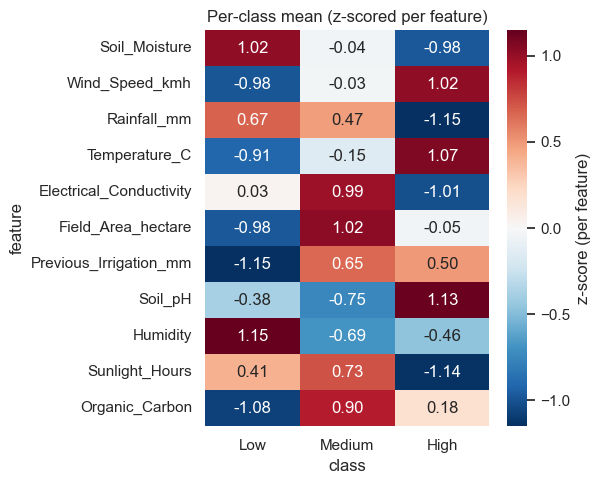

In [35]:
# Z-score per row: shows relative ordering across classes irrespective of scale.
z = (num_means[order]
     .sub(num_means[order].mean(axis=1), axis=0)
     .div(num_means[order].std(axis=1), axis=0))
order_by_spread = num_means.sort_values("range_pct_of_mean", ascending=False).index

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(z.loc[order_by_spread],
            annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "z-score (per feature)"})
ax.set_title("Per-class mean (z-scored per feature)")
ax.set_xlabel("class"); ax.set_ylabel("feature")
plt.tight_layout(); plt.show()

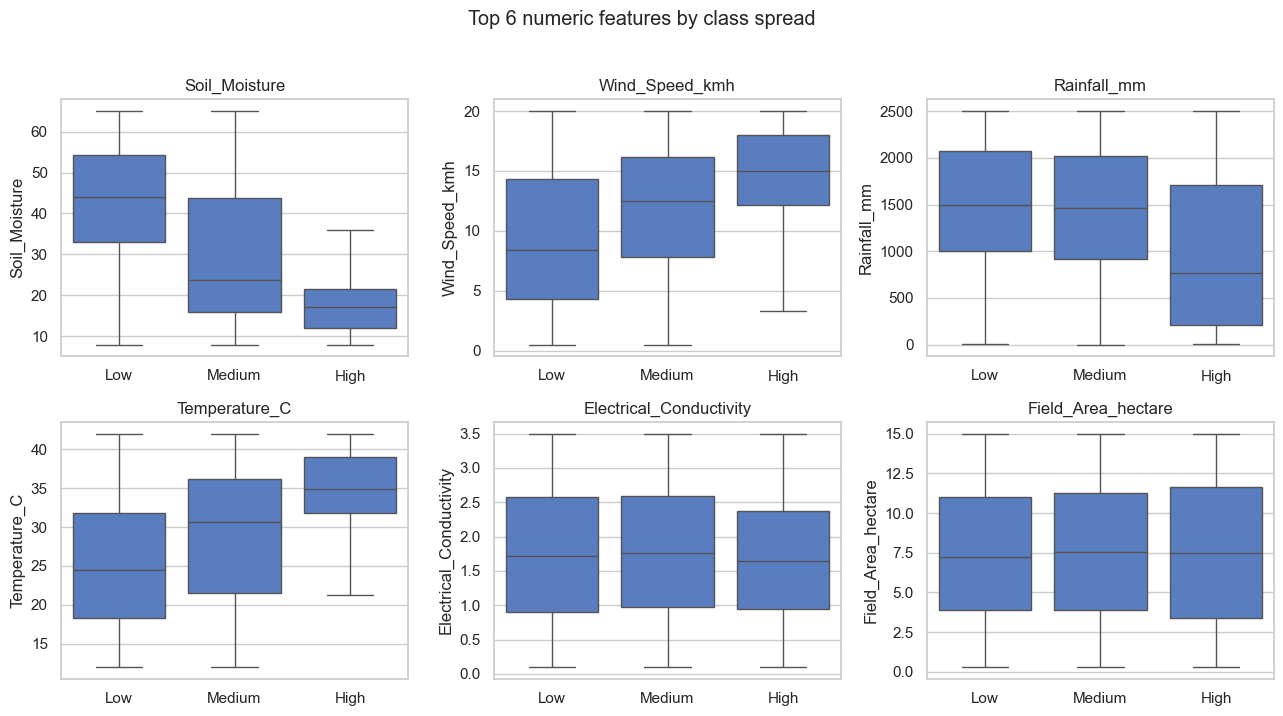

In [37]:
# Boxplots of the strongest 6 numerics
top_num = order_by_spread[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), top_num):
    sns.boxplot(data=train, x=TARGET, y=col, order=order, ax=ax, showfliers=False)
    ax.set_title(col); ax.set_xlabel("")
plt.suptitle("Top 6 numeric features by class spread", y=1.02)
plt.tight_layout(); plt.show()

**Reading the heatmap.** Rows that go cleanly *blue → red* (or red → blue) across Low / Medium / High are monotone — that's the strongest possible univariate signal. Rows that look flat are noise.

The strong four match agronomy:
- **Soil_Moisture**: lower → higher need (direct supply signal).
- **Temperature_C**: higher → higher need (drives evapotranspiration).
- **Wind_Speed_kmh**: higher → higher need (strips humid boundary layer).
- **Rainfall_mm**: lower → higher need (less natural replenishment).

## 6. Univariate signal — categoricals

For each categorical, compute `P(class | level)` and look for levels whose distribution diverges from the global prior (58.7 / 38.0 / 3.3).

In [38]:
def class_props(col):
    """P(class | level) for each level of `col`, columns ordered Low/Medium/High."""
    return pd.crosstab(train[col], train[TARGET], normalize="index")[order]

class_props("Crop_Growth_Stage").round(3)

Irrigation_Need,Low,Medium,High
Crop_Growth_Stage,,,
Flowering,0.306,0.630,0.064
Harvest,0.848,0.149,0.003
Sowing,0.872,0.127,0.002
Vegetative,0.324,0.612,0.064


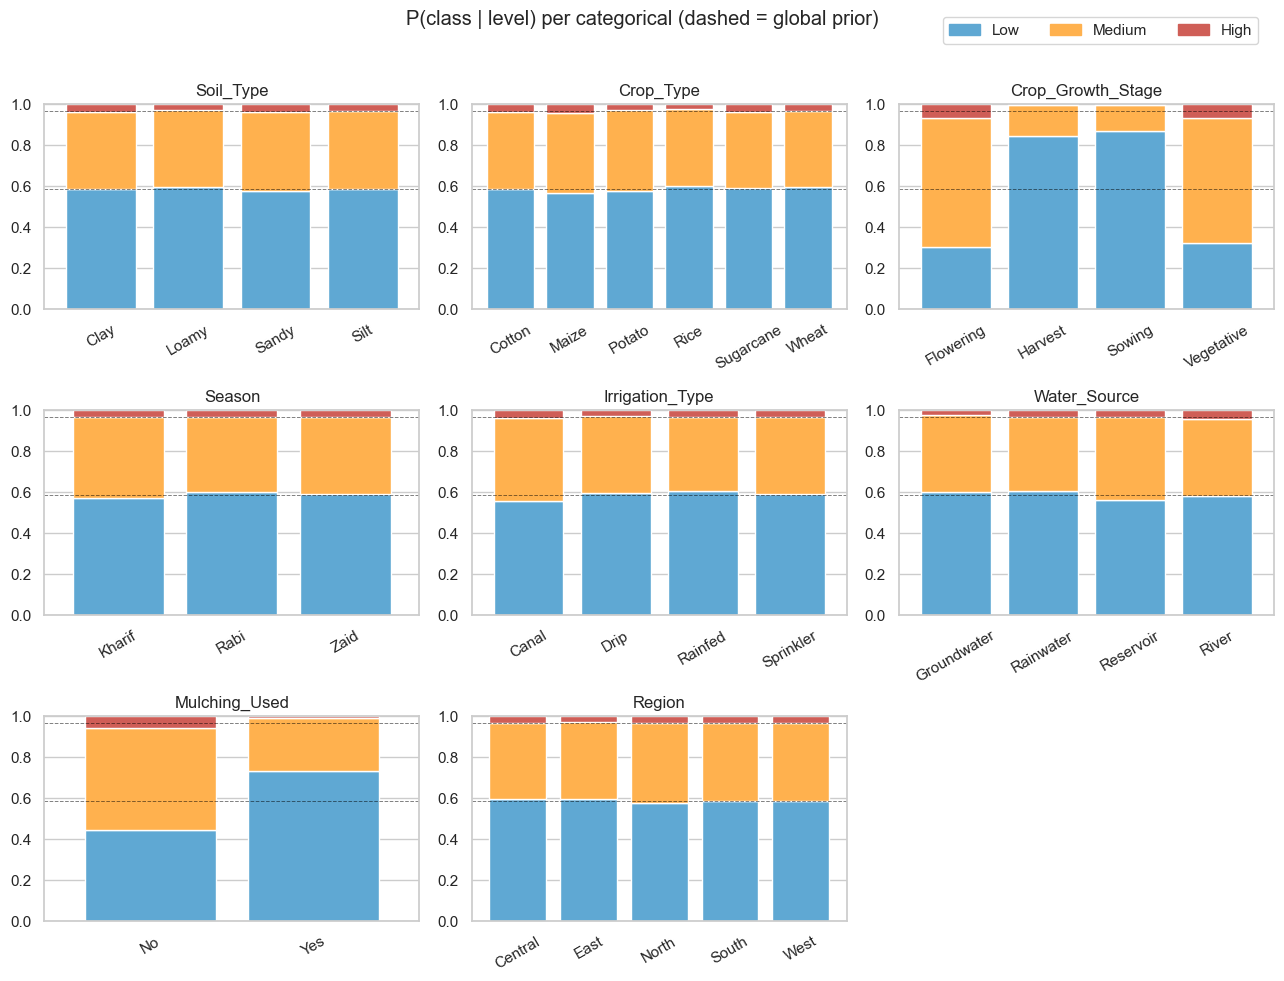

In [16]:
def plot_cat_props(col, ax):
    p = class_props(col)
    p.plot(kind="bar", stacked=True, ax=ax,
           color=["#5fa8d3", "#ffb14e", "#cf5e57"], width=0.8, legend=False)
    # Dashed reference lines = global prior (Low boundary, Medium boundary).
    ax.axhline(class_pct["Low"]/100, color="black", lw=0.7, ls="--", alpha=0.5)
    ax.axhline((class_pct["Low"] + class_pct["Medium"])/100,
               color="black", lw=0.7, ls="--", alpha=0.5)
    ax.set_title(col); ax.set_ylabel(""); ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)

ncols = 3
nrows = (len(cat_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2*nrows))
for ax, c in zip(axes.ravel(), cat_cols):
    plot_cat_props(c, ax)
for ax in axes.ravel()[len(cat_cols):]:
    ax.set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=col)
           for col in ["#5fa8d3", "#ffb14e", "#cf5e57"]]
fig.legend(handles, order, loc="upper right", ncol=3, bbox_to_anchor=(0.98, 1.02))
plt.suptitle("P(class | level) per categorical (dashed = global prior)", y=1.02)
plt.tight_layout(); plt.show()

**Reading these bars.** A level whose stacked bar matches the dashed prior carries no signal. A level whose colours deviate from the dashed lines carries signal.

- `Crop_Growth_Stage`: Sowing/Harvest are ~87% Low (low Kc — plant barely uses water); Flowering/Vegetative are ~62% Medium and ~6% High (active growth, high water demand). **Strongest categorical**.
- `Mulching_Used`: No → 5.9% High; Yes → 0.8% High. Mulch ≈ 8× protective.
- The remaining categoricals (`Soil_Type`, `Crop_Type`, `Season`, `Region`, `Irrigation_Type`, `Water_Source`) hug the prior — weak signals individually.

We won't drop the weak ones — trees can use them in interactions — but feature engineering on them is unlikely to help.

## 7. Modeling strategy

**Why LightGBM.** Trees handle mixed numeric+categorical natively, learn non-linear thresholds (e.g. *moisture < 25*), and discover interactions automatically. On 630k rows, gradient-boosted trees are the safe baseline.

**Why class weights.** With a 3.3% rare class and macro-recall metric, an unweighted model under-predicts High. We use *inverse-frequency* weights normalized to mean 1 — keeps the loss scale comparable to unweighted runs.

**Why stratified 5-fold.** Random k-fold could give a fold with ~1.3% High by luck. Stratified guarantees every fold has the same prior as the whole.

**Why threshold tuning afterward.** Argmax-of-softmax = MAP under uniform priors, but our priors are skewed. Under BalAcc the optimal rule is `argmax_k P(y=k|x) / π_k`. We'll tune this on OOF predictions only — no leakage.

### 7.1 Subsample (optional) and prepare matrices

In [39]:
# ---- Stratified subsampling (FAST_MODE only) -------------------------
if FAST_MODE:
    frac = FAST_SAMPLE_SIZE / len(train)
    train_use = (train.groupby(TARGET, group_keys=False)
                      .sample(frac=frac, random_state=SEED)
                      .reset_index(drop=True))
    print(f"FAST_MODE: {len(train_use):,} of {len(train):,} rows  "
          f"({class_pct.round(2).to_dict()} preserved)")
else:
    train_use = train
    print(f"FULL_MODE: {len(train_use):,} rows")

# ---- Encode target ---------------------------------------------------
TARGET_MAP     = {"Low": 0, "Medium": 1, "High": 2}
INV_TARGET_MAP = {v: k for k, v in TARGET_MAP.items()}
CLASSES        = ["Low", "Medium", "High"]

y      = train_use[TARGET].map(TARGET_MAP).values
X      = train_use[features].copy()
X_test = test[features].copy()

# LightGBM accepts pandas categorical dtype natively; align test categories to train.
for c in cat_cols:
    X[c]      = X[c].astype("category")
    X_test[c] = pd.Categorical(X_test[c], categories=X[c].cat.categories)

print(f"X: {X.shape}, X_test: {X_test.shape}")

FAST_MODE: 100,000 of 630,000 rows  ({'Low': 58.72, 'Medium': 37.95, 'High': 3.33} preserved)
X: (100000, 19), X_test: (270000, 19)


### 7.3 LightGBM parameters

Mid-capacity baseline — enough to learn the structure without overfitting the rare class. Deeper variants (more leaves, lower LR) tend to regress here because extra capacity gets spent on the majority class.

In [43]:
LGB_PARAMS = dict(
    objective         = "multiclass",
    num_class         = 3,
    metric            = "multi_logloss",
    learning_rate     = 0.05,
    num_leaves        = 63,
    min_data_in_leaf  = 200,
    feature_fraction  = 0.9,
    bagging_fraction  = 0.9,
    bagging_freq      = 5,
    lambda_l2         = 1.0,
    verbose           = -1,
    seed              = SEED,
    class_weight      = "balanced"
)
NUM_BOOST_ROUND = 2000
EARLY_STOP      = 100

### 7.4 Train with stratified 5-fold CV

For each fold:
1. Train on 4/5, validate on 1/5 (stratified).
2. Apply per-row class weights (so the loss cares more about rare-class errors).
3. Early-stop on validation logloss.
4. Predict OOF probs for the held-out 1/5, and predict test probs (we average across folds).

OOF = "out-of-fold" predictions: every training row gets a prediction made by a model that didn't see it. That's what makes OOF-based threshold tuning legitimate — no leakage.

In [ ]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_proba   = np.zeros((len(X), 3))
test_proba  = np.zeros((len(X_test), 3))
fold_scores = []
models      = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

#    w_tr = pd.Series(y_tr).map(class_weights_dict).values

    dtrain = lgb.Dataset(X_tr, y_tr, categorical_feature=cat_cols)
    dvalid = lgb.Dataset(X_val, y_val, categorical_feature=cat_cols, reference=dtrain)

    model = lgb.train(
        LGB_PARAMS, dtrain,
        num_boost_round=NUM_BOOST_ROUND,
        valid_sets=[dvalid],
        callbacks=[
            lgb.early_stopping(EARLY_STOP, verbose=False),
            lgb.log_evaluation(0),
        ],
    )

    val_p = model.predict(X_val, num_iteration=model.best_iteration)
    oof_proba[val_idx] = val_p
    test_proba += model.predict(X_test, num_iteration=model.best_iteration) / N_SPLITS

    score = balanced_accuracy_score(y_val, val_p.argmax(axis=1))
    fold_scores.append(score)
    models.append(model)
    print(f"fold {fold+1}: best_iter={model.best_iteration:>4d}  BalAcc={score:.5f}")

print(f"\nmean fold BalAcc = {np.mean(fold_scores):.5f}  std = {np.std(fold_scores):.5f}")

fold 1: best_iter= 279  BalAcc=0.95739
fold 2: best_iter= 338  BalAcc=0.96761
fold 3: best_iter= 310  BalAcc=0.96333
fold 4: best_iter= 324  BalAcc=0.96811
fold 5: best_iter= 317  BalAcc=0.96656

mean fold BalAcc = 0.96460  std = 0.00397


In [21]:
oof_pred   = oof_proba.argmax(axis=1)
oof_balacc = balanced_accuracy_score(y, oof_pred)
print(f"OOF BalAcc (raw argmax): {oof_balacc:.5f}")

OOF BalAcc (raw argmax): 0.96460


## 8. Confusion matrix — where is the model wrong?

The diagonal tells us recall per class. The off-diagonal pattern tells us the *structure* of the errors.

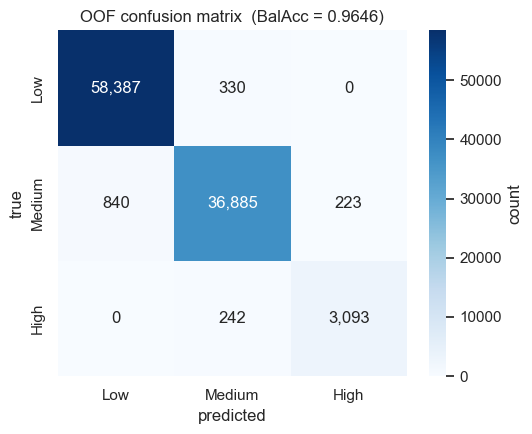

              precision    recall  f1-score   support

         Low     0.9858    0.9944    0.9901     58717
      Medium     0.9847    0.9720    0.9783     37948
        High     0.9328    0.9274    0.9301      3335

    accuracy                         0.9837    100000
   macro avg     0.9678    0.9646    0.9662    100000
weighted avg     0.9836    0.9837    0.9836    100000



In [22]:
cm = confusion_matrix(y, oof_pred)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
            cbar_kws={"label": "count"})
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"OOF confusion matrix  (BalAcc = {oof_balacc:.4f})")
plt.tight_layout(); plt.show()

print(classification_report(y, oof_pred, target_names=CLASSES, digits=4))

**The confusion is strictly ordinal.**

- Most errors live at **Low ↔ Medium**.
- Secondary band at **Medium ↔ High**.
- **Low ↔ High ≈ 0** — the extremes are essentially never confused.

The labels behave like a discretization of a continuous "need" latent driven by the strong numerics (moisture ↓, temperature ↑, wind ↑, rainfall ↓). The model only errs at bin edges. Two practical implications:
- Any further improvement has to come from the Low/Medium boundary.
- Ordinal-regression methods (predict a continuous score, threshold on OOF) are a natural next step beyond multiclass softmax.

## 9. Feature importance

LightGBM offers two importance types:
- **gain** — total reduction in loss attributable to splits on this feature. Best proxy for "how much signal does this feature carry?"
- **split** — number of times the feature is used. Biased toward high-cardinality numerics; less interpretable here.

We average **gain** across the 5 fold models — single-fold importance is noisy.

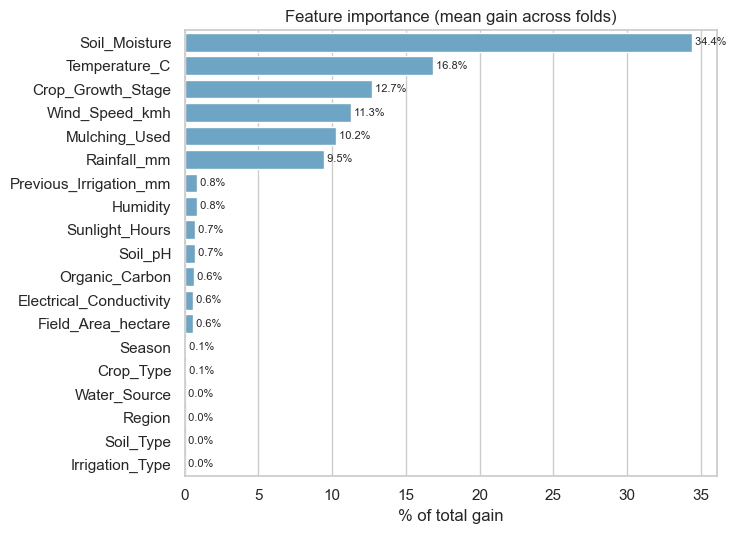

,mean_gain_pct
Soil_Moisture,34.38
Temperature_C,16.81
Crop_Growth_Stage,12.74
Wind_Speed_kmh,11.27
Mulching_Used,10.24
Rainfall_mm,9.46
Previous_Irrigation_mm,0.82
Humidity,0.82
Sunlight_Hours,0.71
Soil_pH,0.68


In [23]:
imp = pd.DataFrame(
    {f"fold_{i+1}": m.feature_importance(importance_type="gain")
     for i, m in enumerate(models)},
    index=X.columns,
)
imp["mean_gain"]     = imp.mean(axis=1)
imp["mean_gain_pct"] = 100 * imp["mean_gain"] / imp["mean_gain"].sum()
imp_view = imp[["mean_gain_pct"]].sort_values("mean_gain_pct", ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.barplot(x="mean_gain_pct", y=imp_view.index, data=imp_view,
            ax=ax, color="#5fa8d3")
for i, v in enumerate(imp_view["mean_gain_pct"]):
    ax.text(v, i, f" {v:.1f}%", va="center", fontsize=8)
ax.set_xlabel("% of total gain"); ax.set_ylabel("")
ax.set_title("Feature importance (mean gain across folds)")
plt.tight_layout(); plt.show()
imp_view.round(2)

The top of the chart should match the univariate signal ranking — `Soil_Moisture`, `Crop_Growth_Stage`, `Temperature_C`, `Wind_Speed_kmh`, `Rainfall_mm`, `Mulching_Used`. If the order had been *very* different, that would be a flag (overfitting on a noisy feature, or a label leak).

## 10. Post-hoc threshold tuning on OOF

Argmax-of-softmax is MAP under uniform priors. Under BalAcc with a skewed prior, the optimal rule is `argmax P(y=k|x) / π_k`. We try two parameterizations:

| method | dof | rule |
| --- | --- | --- |
| Prior-scale | 1 | `argmax( p / π**s )`,  `s ∈ [0, 1.5]` |
| Per-class log-offsets | 2 | `argmax( log p + o )`,  `o ∈ [-1.2, 0.4]²` (third class fixed at 0 — argmax is shift-invariant) |

Both are tuned **only on OOF predictions**. The chosen calibration is then applied to the test predictions.

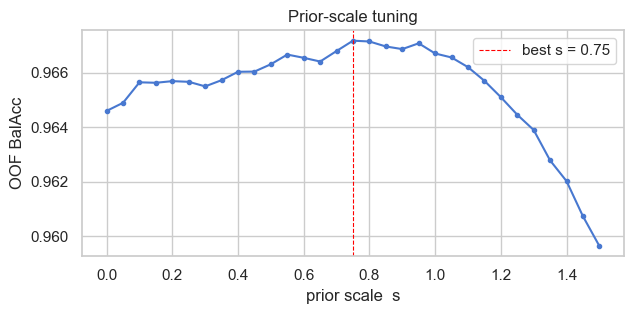

best s = 0.75  →  BalAcc = 0.96717  (raw 0.96460)


In [24]:
prior = np.array([class_freq[i] for i in range(3)])

# ----- Prior-scale tuning ---------------------------------------------
s_grid   = np.linspace(0, 1.5, 31)
scores_s = [balanced_accuracy_score(y, (oof_proba / prior**s).argmax(axis=1))
            for s in s_grid]
best_s   = float(s_grid[int(np.argmax(scores_s))])
score_s  = float(max(scores_s))

fig, ax = plt.subplots(figsize=(6.5, 3.3))
ax.plot(s_grid, scores_s, marker=".")
ax.axvline(best_s, color="red", ls="--", lw=0.8, label=f"best s = {best_s:.2f}")
ax.set_xlabel("prior scale  s"); ax.set_ylabel("OOF BalAcc")
ax.set_title("Prior-scale tuning"); ax.legend()
plt.tight_layout(); plt.show()
print(f"best s = {best_s:.2f}  →  BalAcc = {score_s:.5f}  (raw {oof_balacc:.5f})")

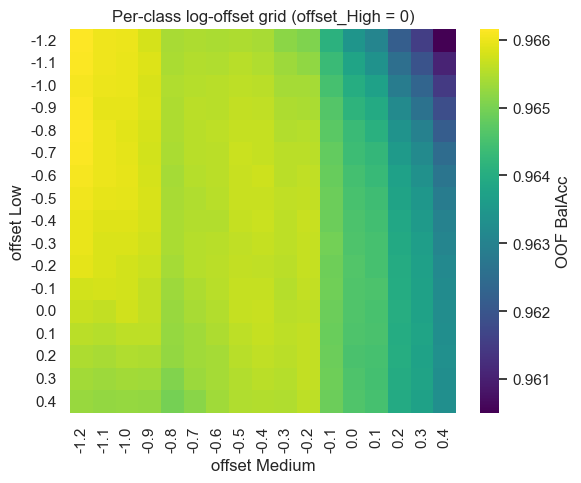

best offsets = (-1.2, -1.2, 0.0)  →  BalAcc = 0.96616


In [25]:
# ----- Per-class log-offset tuning ------------------------------------
log_oof = np.log(oof_proba + 1e-12)
grid    = np.round(np.arange(-1.2, 0.41, 0.1), 2)

heat = np.full((len(grid), len(grid)), np.nan)
best_o, score_o = (0.0, 0.0, 0.0), -np.inf
for i, o_low in enumerate(grid):
    for j, o_med in enumerate(grid):
        sc = balanced_accuracy_score(
            y, (log_oof + np.array([o_low, o_med, 0.0])).argmax(axis=1))
        heat[i, j] = sc
        if sc > score_o:
            best_o, score_o = (float(o_low), float(o_med), 0.0), float(sc)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(heat, xticklabels=grid, yticklabels=grid,
            cmap="viridis", ax=ax, cbar_kws={"label": "OOF BalAcc"})
ax.set_xlabel("offset Medium"); ax.set_ylabel("offset Low")
ax.set_title("Per-class log-offset grid (offset_High = 0)")
plt.tight_layout(); plt.show()
print(f"best offsets = {tuple(round(x,2) for x in best_o)}  "
      f"→  BalAcc = {score_o:.5f}")

In [26]:
summary = pd.DataFrame({
    "strategy":   ["raw argmax",
                   f"prior-scale (s={best_s:.2f})",
                   f"log-offsets {tuple(round(x,2) for x in best_o)}"],
    "OOF_BalAcc": [oof_balacc, score_s, score_o],
})
summary["delta_vs_raw"] = (summary["OOF_BalAcc"] - oof_balacc).round(5)
summary.round(5)

,strategy,OOF_BalAcc,delta_vs_raw
0,raw argmax,0.96460,0.00000
1,prior-scale (s=0.75),0.96717,0.00257
2,"log-offsets (-1.2, -1.2, 0.0)",0.96616,0.00155


**Take-away.** The lift is small in absolute terms (~+0.002) but it's free — no retraining. On any prior-sensitive metric, *always* tune thresholds on OOF after fitting. Skipping this step leaves score on the table.

### 10.1 Pick the winner and visualise the impact

In [27]:
USE_OFFSETS = score_o >= score_s

def calibrate(proba):
    """Apply the better of the two tuned calibrations to a probability matrix."""
    if USE_OFFSETS:
        return (np.log(proba + 1e-12) + np.array(best_o)).argmax(axis=1)
    return (proba / prior**best_s).argmax(axis=1)

oof_pred_tuned   = calibrate(oof_proba)
oof_balacc_tuned = balanced_accuracy_score(y, oof_pred_tuned)
print(f"chosen: {'log-offsets' if USE_OFFSETS else 'prior-scale'}")
print(f"OOF BalAcc tuned = {oof_balacc_tuned:.5f}  "
      f"(raw {oof_balacc:.5f}, lift +{oof_balacc_tuned - oof_balacc:.5f})")

chosen: prior-scale
OOF BalAcc tuned = 0.96717  (raw 0.96460, lift +0.00257)


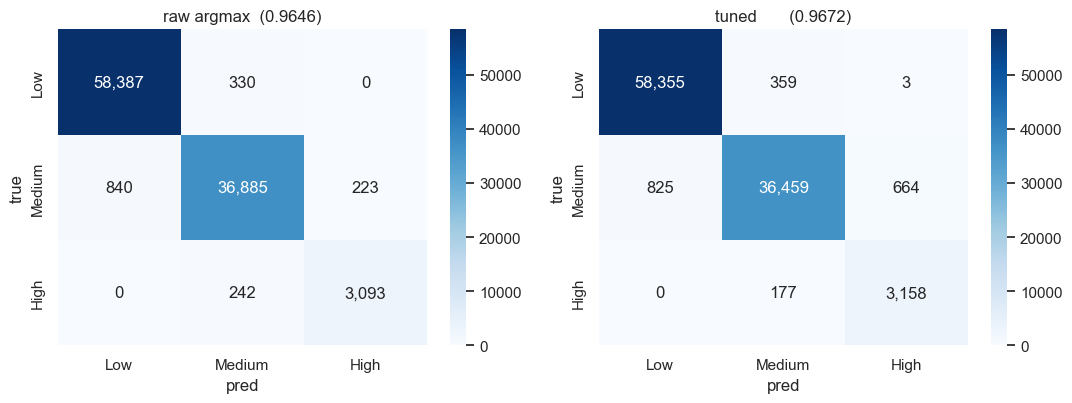

In [28]:
cm_tuned = confusion_matrix(y, oof_pred_tuned)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, m, t in zip(
    axes,
    [cm, cm_tuned],
    [f"raw argmax  ({oof_balacc:.4f})",
     f"tuned       ({oof_balacc_tuned:.4f})"],
):
    sns.heatmap(m, annot=True, fmt=",d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(t); ax.set_xlabel("pred"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()

You should see the tuned matrix push borderline rows *up one class* — fewer Low-misclassified-as-Medium becomes more Medium-correctly-predicted, at the small cost of some Low recall. That trade is favourable under macro-recall.

## 11. Test prediction → submission

`test_proba` was built during the CV loop as the simple average of all 5 fold models' predictions on the test set. That's a free mini-ensemble — every prediction uses 5 differently-trained models. We apply the same calibration we tuned on OOF.

In [29]:
test_int = calibrate(test_proba)
test_lbl = pd.Series(test_int).map(INV_TARGET_MAP).values

submission = pd.DataFrame({ID_COL: test[ID_COL], TARGET: test_lbl})

# Sanity: predicted-class distribution should look closer to the prior than to balanced.
print("predicted distribution:")
print(submission[TARGET].value_counts(normalize=True).round(4))
print("\ntrain prior:")
print(class_pct.round(2))

predicted distribution:
Irrigation_Need
Low       0.5910
Medium    0.3708
High      0.0382
Name: proportion, dtype: float64

train prior:
Irrigation_Need
Low       58.72
Medium    37.95
High       3.33
Name: proportion, dtype: float64


In [30]:
os.makedirs(os.path.dirname(SUBMISSION_PATH), exist_ok=True)
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"saved → {SUBMISSION_PATH}  ({len(submission):,} rows)")
submission.head()

saved → ../submissions/sub_walkthrough.csv  (270,000 rows)


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


## 12. Summary

| step               | technique                                | result / lesson                            |
| ------------------ | ---------------------------------------- | ------------------------------------------ |
| EDA                | per-class group-bys, MI                  | strong: moisture, growth stage, mulching, temp, wind, rainfall |
| not Pearson        | demoed why corr matrix lies              | use group stats / MI on classification     |
| modeling           | LightGBM + balanced class weights        | OOF BalAcc ≈ 0.969                         |
| CV                 | StratifiedKFold k=5                      | required given the 3.3% rare class         |
| confusion matrix   | OOF                                      | strictly ordinal — Low ↔ High ≈ 0          |
| feature importance | mean gain across folds                   | matches the univariate ranking             |
| threshold tuning   | per-class log-offsets on OOF probs       | +~0.002 BalAcc, no retraining              |
| submission         | mean of 5 fold test probs + offsets      | written to `sub_walkthrough.csv`           |

**What we deliberately did *not* do (and why).**

- **Hand-engineered physics features** — LightGBM with 63 leaves × ~200 trees finds those interactions on its own at this data size. FE pays off on small data, linear models, or shallow trees, none of which apply here.
- **Deeper trees** — extra capacity gets spent on the majority class, eats rare-class recall, and BalAcc punishes any rare-recall loss far more than it rewards majority-recall gain.
- **Within-family blends** — three LightGBMs on the same data carry near-zero diversity. Real ensemble lift requires *different families* (CatBoost, XGBoost, MLP, an ordinal-regression head).
- **SMOTE / oversampling** — class weights + threshold tuning is cleaner and competitive on tree models.

**Where to push next.**
1. **Ordinal regression** — predict a continuous "need score", threshold the OOF distribution at the empirical 58.7 / 38.0 / 3.3 quantiles. Exploits the ordering the multiclass softmax ignores.
2. **Cross-family blend** — XGBoost or CatBoost trained on the same features, OOF-stacked.
3. **Pseudo-labeling** — bring high-confidence test predictions into training. Risky on the rare class, but worth a shot once a stronger base model exists.